# Trabalho de Sistemas Integrados - ETL, Análise e Visualização
## Análise de Jogadores das 5 Grandes Ligas Europeias - Temporada 2019/20

**Disciplina:** Sistemas Integrados de Gestão e Aplicações  
**Professor:** Ricardo Leme  
**Dataset:** Transfermarkt + FBref (Kaggle)  
**Integrantes:** Luis Felipe e Vinicius Lisboa

---

## Sobre o projeto
Este notebook faz o processo de **ETL** (Extract, Transform, Load), análise exploratória e dashboard de uma base real de jogadores das 5 grandes ligas europeias (Premier League, La Liga, Serie A, Bundesliga e Ligue 1) na temporada **2019/20**.

Os dados combinam informações do **Transfermarkt** (valor de mercado dos jogadores) com estatísticas de desempenho do **FBref** (gols, assistências, minutos jogados, etc.).

## 1. Importação das bibliotecas

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

## 2. EXTRACT — Carregar o CSV


In [2]:
df = pd.read_csv('transfermarkt_fbref_201920-1.csv', sep=';', encoding='utf-8', low_memory=False)

print(f'Total de linhas: {len(df)}')
print(f'Total de colunas: {len(df.columns)}')

Total de linhas: 2644
Total de colunas: 400


In [5]:
# O dataset original tem 400 colunas. Vamos selecionar só as que vamos usar
colunas_uteis = ['player', 'nationality', 'position', 'squad', 'age', 'value',
                 'league', 'games', 'minutes', 'goals', 'assists']

df = df[colunas_uteis].copy()

df.head()

,player,nationality,position,squad,age,value,league,games,minutes,goals,assists
0,Martin Aguirregabiria,es ESP,DF,AlavĂ©s,23,4000000,La Liga,31,2099,1,1
1,Oliver Burke,sco SCO,"MF,FW",AlavĂ©s,22,4000000,La Liga,31,1429,1,2
2,VĂ­ctor Camarasa,es ESP,MF,AlavĂ©s,25,4000000,La Liga,17,1293,0,1
3,RubĂ©n Duarte,es ESP,DF,AlavĂ©s,23,4000000,La Liga,31,2663,0,1
4,Rodrigo Ely,br BRA,DF,AlavĂ©s,25,1000000,La Liga,25,2121,2,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   player       2644 non-null   object
 1   nationality  2644 non-null   object
 2   position     2644 non-null   object
 3   squad        2644 non-null   object
 4   age          2644 non-null   int64 
 5   value        2644 non-null   int64 
 6   league       2644 non-null   object
 7   games        2644 non-null   int64 
 8   minutes      2644 non-null   int64 
 9   goals        2644 non-null   int64 
 10  assists      2644 non-null   int64 
dtypes: int64(6), object(5)
memory usage: 227.3+ KB


### Entendendo as colunas

- **player**: nome do jogador  
- **nationality**: nacionalidade (ex: br BRA, es ESP)  
- **position**: posição (GK = goleiro, DF = defensor, MF = meio-campo, FW = atacante)  
- **squad**: clube  
- **age**: idade  
- **value**: valor de mercado em euros (€)  
- **league**: liga (Premier League, La Liga, Serie A, Bundesliga, Ligue 1)  
- **games**: jogos disputados na temporada  
- **minutes**: minutos jogados na temporada  
- **goals**: gols marcados  
- **assists**: assistências

## 3. TRANSFORM — Limpeza dos dados

1. Verificar e remover linhas duplicadas
2. Verificar valores ausentes
3. Limpar a coluna de nacionalidade (vem com código país junto, ex: 'br BRA')
4. Renomear colunas pra português
5. Converter o valor de mercado pra milhões de euros (mais fácil de ler)

In [ ]:
# 3.1 - Remover duplicatas
qtd_antes = len(df)
df = df.drop_duplicates()
qtd_depois = len(df)

print(f'Duplicatas removidas: {qtd_antes - qtd_depois}')
print(f'Linhas restantes: {qtd_depois}')

Duplicatas removidas: 0
Linhas restantes: 2644


In [ ]:
# 3.2 - Verificar valores ausentes em cada coluna
print('Valores ausentes por coluna:')
print(df.isnull().sum())

Valores ausentes por coluna:
player         0
nationality    0
position       0
squad          0
age            0
value          0
league         0
games          0
minutes        0
goals          0
assists        0
dtype: int64


In [ ]:
# 3.3 - Limpar a coluna nacionalidade (vem como 'br BRA', queremos só 'BRA')
df['nationality'] = df['nationality'].str.split(' ').str[-1]

# 3.4 - Renomear colunas pra português
df = df.rename(columns={
    'player': 'jogador',
    'nationality': 'nacionalidade',
    'position': 'posicao',
    'squad': 'clube',
    'age': 'idade',
    'value': 'valor_mercado',
    'league': 'liga',
    'games': 'jogos',
    'minutes': 'minutos',
    'goals': 'gols',
    'assists': 'assistencias'
})

# 3.5 - Converter valor de mercado pra milhões de euros
df['valor_mercado_milhoes'] = df['valor_mercado'] / 1_000_000

# 3.6 - Criar coluna de participações em gols (gols + assistências)
df['participacoes_gols'] = df['gols'] + df['assistencias']

df.head()

,jogador,nacionalidade,posicao,clube,idade,valor_mercado,liga,jogos,minutos,gols,assistencias,valor_mercado_milhoes,participacoes_gols
0,Martin Aguirregabiria,ESP,DF,AlavÄÂ©s,23,4000000,La Liga,31,2099,1,1,4.0,2
1,Oliver Burke,SCO,"MF,FW",AlavÄÂ©s,22,4000000,La Liga,31,1429,1,2,4.0,3
2,VÄÂ­ctor Camarasa,ESP,MF,AlavÄÂ©s,25,4000000,La Liga,17,1293,0,1,4.0,1
3,RubÄÂ©n Duarte,ESP,DF,AlavÄÂ©s,23,4000000,La Liga,31,2663,0,1,4.0,1
4,Rodrigo Ely,BRA,DF,AlavÄÂ©s,25,1000000,La Liga,25,2121,2,0,1.0,2


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   jogador                2644 non-null   object 
 1   nacionalidade          2644 non-null   object 
 2   posicao                2644 non-null   object 
 3   clube                  2644 non-null   object 
 4   idade                  2644 non-null   int64  
 5   valor_mercado          2644 non-null   int64  
 6   liga                   2644 non-null   object 
 7   jogos                  2644 non-null   int64  
 8   minutos                2644 non-null   int64  
 9   gols                   2644 non-null   int64  
 10  assistencias           2644 non-null   int64  
 11  valor_mercado_milhoes  2644 non-null   float64
 12  participacoes_gols     2644 non-null   int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 268.7+ KB


## 4. ANÁLISE — KPIs do negócio

1. Quais os **10 jogadores mais valiosos** da temporada?
2. Quais os **10 maiores artilheiros** da temporada?
3. Qual a **idade média** e o **valor médio** dos jogadores por liga?
4. Quais **clubes** têm o elenco mais caro?

### KPI 1 — Top 10 jogadores mais valiosos

In [ ]:
top_valor = (
    df.sort_values('valor_mercado', ascending=False)
      [['jogador', 'clube', 'liga', 'idade', 'valor_mercado_milhoes']]
      .head(10)
)
top_valor

,jogador,clube,liga,idade,valor_mercado_milhoes
1858,Kylian MbappÄÂ©,Paris S-G,Ligue 1,20,180.0
1862,Neymar,Paris S-G,Ligue 1,27,128.0
1430,Raheem Sterling,Manchester City,Premier League,24,128.0
1321,Sadio ManÄÂ©,Liverpool,Premier League,27,120.0
1415,Kevin De Bruyne,Manchester City,Premier League,28,120.0
2341,Harry Kane,Tottenham,Premier League,26,120.0
1328,Mohamed Salah,Liverpool,Premier League,27,120.0
695,Jadon Sancho,Dortmund,Bundesliga,19,117.0
257,Lionel Messi,Barcelona,La Liga,32,112.0
1309,Trent Alexander-Arnold,Liverpool,Premier League,20,99.0


### KPI 2 — Top 10 artilheiros da temporada

In [ ]:
top_artilheiros = (
    df.sort_values('gols', ascending=False)
      [['jogador', 'clube', 'liga', 'gols', 'assistencias']]
      .head(10)
)
top_artilheiros

,jogador,clube,liga,gols,assistencias
1139,Ciro Immobile,Lazio,Serie A,36,9
283,Robert Lewandowski,Bayern Munich,Bundesliga,34,4
1093,Cristiano Ronaldo,Juventus,Serie A,31,5
1920,Timo Werner,RB Leipzig,Bundesliga,28,8
257,Lionel Messi,Barcelona,La Liga,25,21
1055,Romelu Lukaku,Inter,Serie A,23,2
1235,Jamie Vardy,Leicester City,Premier League,23,5
79,Pierre-Emerick Aubameyang,Arsenal,Premier League,22,3
2233,Danny Ings,Southampton,Premier League,22,2
1925,Karim Benzema,Real Madrid,La Liga,21,8


### KPI 3 — Idade média e valor médio por liga

In [ ]:
analise_liga = df.groupby('liga').agg(
    qtd_jogadores=('jogador', 'count'),
    idade_media=('idade', 'mean'),
    valor_medio_milhoes=('valor_mercado_milhoes', 'mean'),
    valor_total_milhoes=('valor_mercado_milhoes', 'sum')
).round(2)

analise_liga = analise_liga.sort_values('valor_total_milhoes', ascending=False)
analise_liga

,qtd_jogadores,idade_media,valor_medio_milhoes,valor_total_milhoes
liga,,,,
Premier League,511,25.60,15.55,7944.94
La Liga,538,25.90,9.54,5131.89
Serie A,585,25.54,8.09,4734.73
Bundesliga,487,24.99,8.75,4262.68
Ligue 1,523,24.50,6.18,3230.49


### KPI 4 — Top 10 clubes com elenco mais caro

In [ ]:
top_clubes = (
    df.groupby('clube')['valor_mercado_milhoes']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)
top_clubes

,valor_mercado_milhoes
clube,
Manchester City,1037.0000
Liverpool,963.0000
Barcelona,928.5000
Paris S-G,877.0909
Real Madrid,848.0000
Tottenham,777.0000
Bayern Munich,750.1900
AtlÄÂ©tico Madrid,742.1950
Chelsea,673.5600


## 5. VISUALIZAÇÃO — Dashboard com 5 gráficos

### Gráfico 1 — Top 10 jogadores mais valiosos

/tmp/ipykernel_7047/4172672203.py:7: UserWarning: Glyph 130 (\x82) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 130 (\x82) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


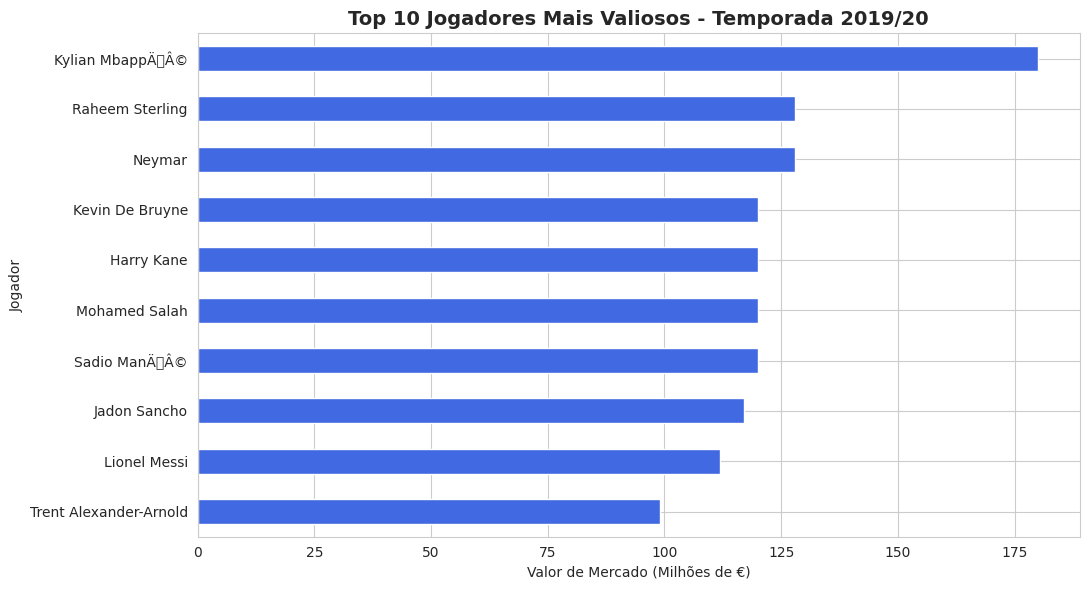

In [ ]:
plt.figure(figsize=(11, 6))
dados = top_valor.set_index('jogador')['valor_mercado_milhoes'].sort_values()
dados.plot(kind='barh', color='royalblue')
plt.title('Top 10 Jogadores Mais Valiosos - Temporada 2019/20', fontsize=14, fontweight='bold')
plt.xlabel('Valor de Mercado (Milhões de €)')
plt.ylabel('Jogador')
plt.tight_layout()
plt.show()

### Gráfico 2 — Top 10 artilheiros

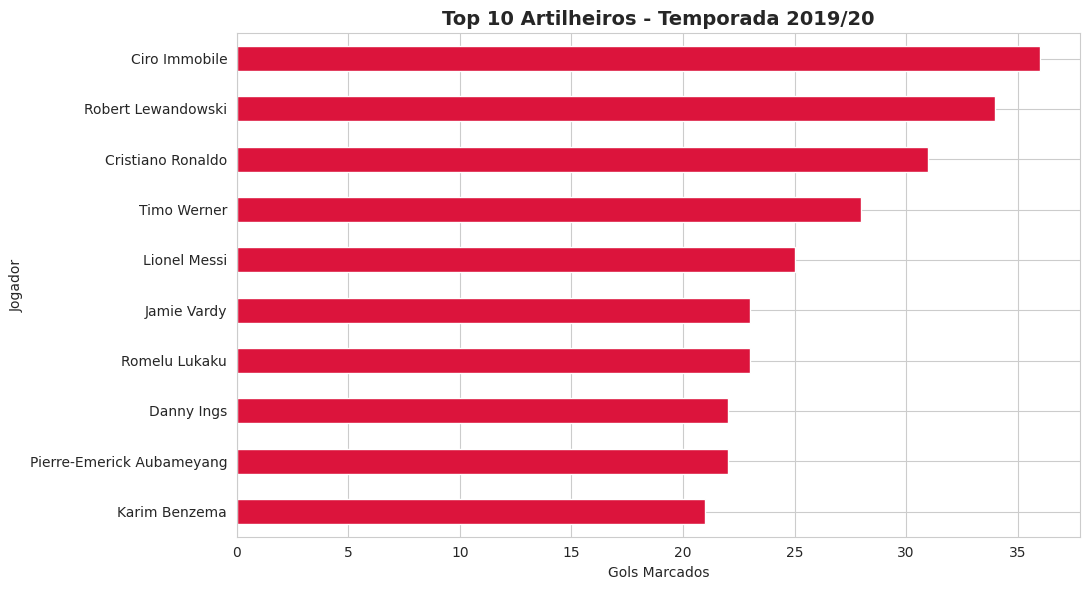

In [ ]:
plt.figure(figsize=(11, 6))
dados_art = top_artilheiros.set_index('jogador')['gols'].sort_values()
dados_art.plot(kind='barh', color='crimson')
plt.title('Top 10 Artilheiros - Temporada 2019/20', fontsize=14, fontweight='bold')
plt.xlabel('Gols Marcados')
plt.ylabel('Jogador')
plt.tight_layout()
plt.show()

### Gráfico 3 — Comparação de valor total por liga

/tmp/ipykernel_7047/2081667836.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=analise_liga.index, y=analise_liga['valor_total_milhoes'], palette='viridis')


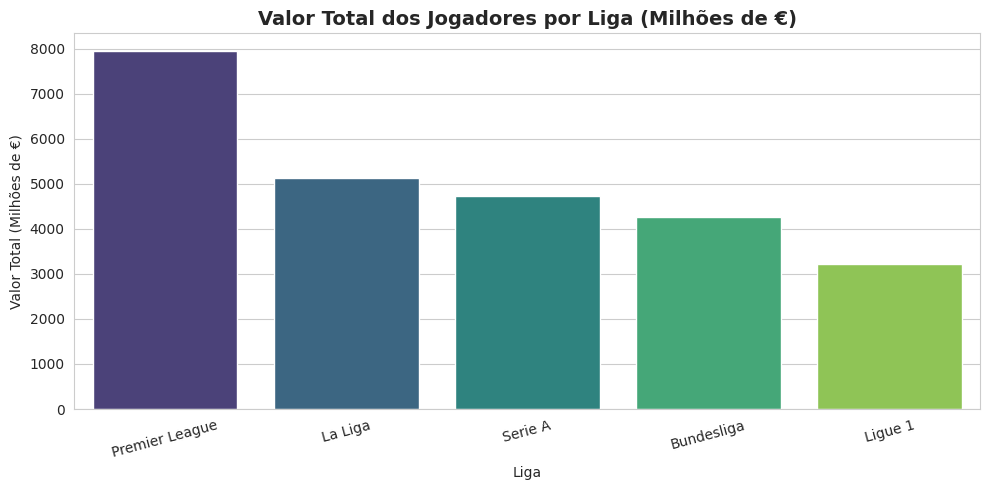

In [ ]:
plt.figure(figsize=(10, 5))
sns.barplot(x=analise_liga.index, y=analise_liga['valor_total_milhoes'], palette='viridis')
plt.title('Valor Total dos Jogadores por Liga (Milhões de €)', fontsize=14, fontweight='bold')
plt.xlabel('Liga')
plt.ylabel('Valor Total (Milhões de €)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### Gráfico 4 — Distribuição de idade dos jogadores

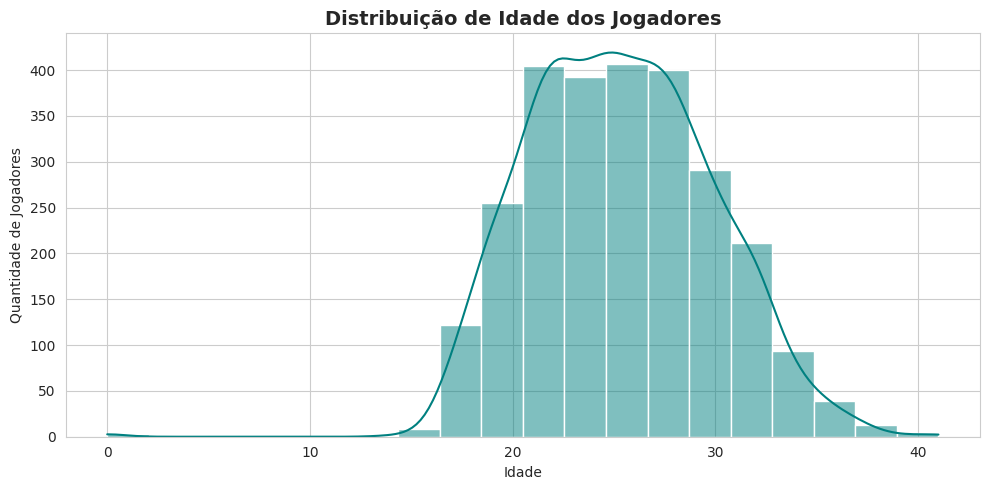

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='idade', bins=20, color='teal', kde=True)
plt.title('Distribuição de Idade dos Jogadores', fontsize=14, fontweight='bold')
plt.xlabel('Idade')
plt.ylabel('Quantidade de Jogadores')
plt.tight_layout()
plt.show()

### Gráfico 5 — Relação entre minutos jogados e gols (atacantes)

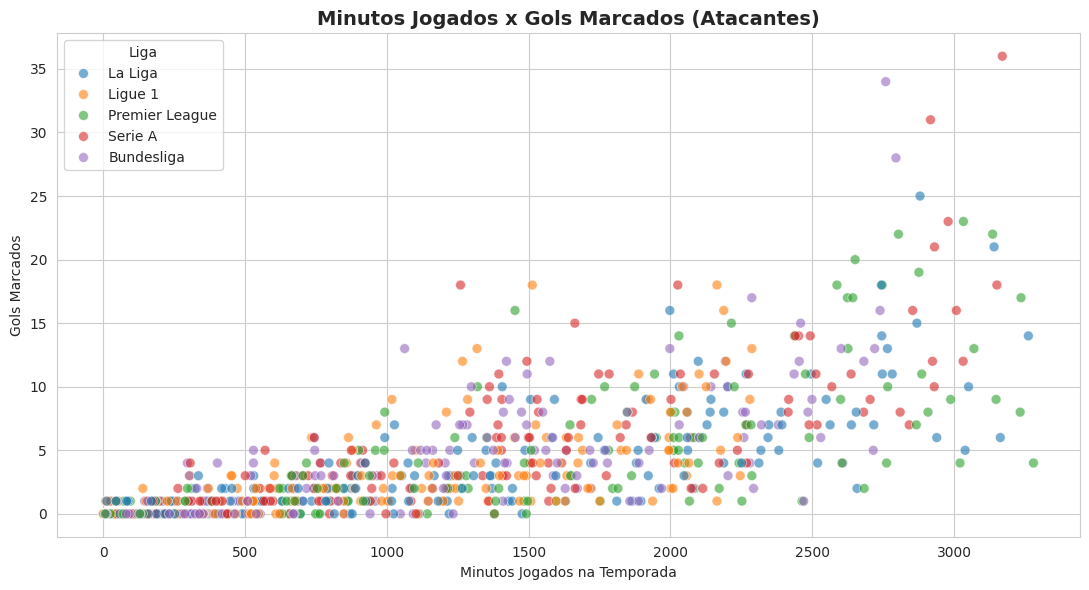

In [ ]:
# Filtra só atacantes pra ter uma análise mais relevante
atacantes = df[df['posicao'].str.contains('FW', na=False)]

plt.figure(figsize=(11, 6))
sns.scatterplot(data=atacantes, x='minutos', y='gols', hue='liga', alpha=0.6, s=50)
plt.title('Minutos Jogados x Gols Marcados (Atacantes)', fontsize=14, fontweight='bold')
plt.xlabel('Minutos Jogados na Temporada')
plt.ylabel('Gols Marcados')
plt.legend(title='Liga')
plt.tight_layout()
plt.show()

## 6. Conclusão

A análise da temporada 2019/20 das 5 grandes ligas europeias mostra:

- A **Premier League** é a liga com maior valor total de jogadores, confirmando ser o campeonato mais rico do mundo.
- Os **jogadores mais valiosos** se concentram em poucos clubes gigantes (Barcelona, Real Madrid, PSG, Manchester City, etc.).
- A **idade média** dos jogadores fica entre 24 e 26 anos, com distribuição concentrada nessa faixa de "ápice" da carreira.
- Existe forte correlação entre **minutos jogados e gols** entre atacantes, mas com outliers claros (jogadores que produzem muito acima da média).
- Os top 10 clubes em valor de elenco somam mais que ligas inteiras de menor porte.

*(Confira os números reais que aparecerem na sua execução e ajuste a conclusão se necessário.)*